# BusinessPulse-AI: Customer Churn Prediction
## Model Training & Evaluation

### Overview

This notebook focuses on building, evaluating, and selecting the best machine learning model for predicting customer churn. It includes data preprocessing, model comparison, hyperparameter tuning, and model serialization for deployment.

### Objectives

- Prepare data for machine learning.
- Train and compare multiple classification models.
- Select the best model based on **F1-Score**.
- Optimize the best-performing model.
- Save deployment-ready artifacts for FastAPI and Streamlit.

In [1]:
# ============================================================
# BusinessPulse-AI : Model Training & Evaluation
# Notebook : 02_Model_Training.ipynb
# ============================================================

print("=" * 65)
print("BusinessPulse-AI : Customer Churn Prediction")
print("Model Training & Evaluation Notebook")
print("=" * 65)

BusinessPulse-AI : Customer Churn Prediction
Model Training & Evaluation Notebook


### Observation

The notebook environment has been initialized successfully and is ready for data preprocessing, model training, evaluation, and deployment.

## 📚 2. Import Required Libraries

This section imports all the libraries required for data preprocessing, machine learning, model evaluation, visualization, hyperparameter tuning, and model serialization. The libraries are grouped logically to improve readability and maintainability.

In [2]:
# ============================================================
# Standard Libraries
# ============================================================
import warnings
import joblib

# ============================================================
# Data Manipulation
# ============================================================
import numpy as np
import pandas as pd

# ============================================================
# Data Visualization
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Data Preprocessing
# ============================================================
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer

# ============================================================
# Model Selection
# ============================================================
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

# ============================================================
# Machine Learning Models
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier

# ============================================================
# Model Evaluation
# ============================================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# ============================================================
# Ignore Warnings
# ============================================================
warnings.filterwarnings("ignore")

print("✅ All required libraries imported successfully.")

✅ All required libraries imported successfully.


### Observation

All required libraries have been imported successfully. The notebook environment is now ready for data preprocessing, model development, evaluation, hyperparameter tuning, and deployment.

## 📂 3. Load & Prepare Dataset

This section loads the cleaned customer churn dataset, removes unnecessary columns, and prepares the input features (`X`) and target variable (`y`) for machine learning. The dataset preview and dimensions are displayed to verify successful loading.

In [3]:
# ============================================================
# Load & Prepare Dataset
# ============================================================

# Load cleaned dataset
churn_df = pd.read_csv("../data/customer_churn_clean.csv")

# Display dataset information
print("=" * 65)
print("Dataset Loaded Successfully")
print("=" * 65)

print(f"Dataset Shape : {churn_df.shape}")

print("\nFirst 5 Records:")
display(churn_df.head())

# ------------------------------------------------------------
# Prepare Features & Target
# ------------------------------------------------------------

# Remove identifier column
churn_df = churn_df.drop(columns=["customerID"])

# Separate features and target
X = churn_df.drop(columns=["Churn"])
y = churn_df["Churn"]

print("\n" + "=" * 65)
print("Features & Target Prepared Successfully")
print("=" * 65)

print(f"Feature Matrix (X) Shape : {X.shape}")
print(f"Target Vector (y) Shape  : {y.shape}")

Dataset Loaded Successfully
Dataset Shape : (7032, 21)

First 5 Records:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Features & Target Prepared Successfully
Feature Matrix (X) Shape : (7032, 19)
Target Vector (y) Shape  : (7032,)


## 🏷️ 4. Target Encoding

Machine learning algorithms require the target variable to be in numerical format. This section encodes the target labels (`Yes` and `No`) into binary values using `LabelEncoder`.

Encoding Mapping:
- **No → 0**
- **Yes → 1**

In [4]:
# ============================================================
# Target Encoding
# ============================================================

# Initialize Label Encoder
target_encoder = LabelEncoder()

# Encode target variable
y = target_encoder.fit_transform(y)

print("=" * 65)
print("Target Encoding Completed Successfully")
print("=" * 65)

print("\nEncoding Mapping:")

for label, value in zip(
    target_encoder.classes_,
    target_encoder.transform(target_encoder.classes_)
):
    print(f"{label} --> {value}")

print("\nFirst 10 Encoded Target Values:")
print(y[:10])

Target Encoding Completed Successfully

Encoding Mapping:
No --> 0
Yes --> 1

First 10 Encoded Target Values:
[0 0 1 0 1 1 0 0 1 0]


### Observation

The target variable has been successfully converted into numerical values using `LabelEncoder`. The encoded target is now ready for machine learning model training while preserving the original class mapping for deployment.

## 🏗️ 5. Feature Encoding

Machine learning algorithms require numerical input features. This section identifies categorical and numerical features, applies One-Hot Encoding to categorical variables, and retains numerical features without modification using a `ColumnTransformer`.

The encoded feature matrix is then prepared for model training.

In [5]:
# ============================================================
# Feature Encoding
# ============================================================

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("=" * 65)
print("Feature Categories")
print("=" * 65)

print(f"Categorical Features : {len(categorical_features)}")
print(f"Numerical Features   : {len(numerical_features)}")

print("\nCategorical Columns:")
print(categorical_features)

print("\nNumerical Columns:")
print(numerical_features)

# ------------------------------------------------------------
# Create Feature Encoder
# ------------------------------------------------------------

feature_encoder = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

# Encode Features
X_encoded = feature_encoder.fit_transform(X)

print("\n" + "=" * 65)
print("Feature Encoding Completed Successfully")
print("=" * 65)

print(f"Encoded Feature Matrix Shape : {X_encoded.shape}")

Feature Categories
Categorical Features : 15
Numerical Features   : 4

Categorical Columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical Columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Feature Encoding Completed Successfully
Encoded Feature Matrix Shape : (7032, 30)


### Observation

Categorical features have been successfully transformed using One-Hot Encoding, while numerical features remain unchanged. The resulting encoded feature matrix is now suitable for machine learning model training.

## 📊 6. Train-Test Split

To evaluate model performance on unseen data, the encoded dataset is divided into training and testing sets using an 80:20 ratio. Stratified sampling is applied to preserve the original class distribution in both subsets.

A fixed `random_state` is used to ensure reproducibility of the results.

In [6]:
# ============================================================
# Train-Test Split
# ============================================================

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 65)
print("Train-Test Split Completed Successfully")
print("=" * 65)

print(f"Training Features : {X_train.shape}")
print(f"Testing Features  : {X_test.shape}")
print(f"Training Target   : {y_train.shape}")
print(f"Testing Target    : {y_test.shape}")

Train-Test Split Completed Successfully
Training Features : (5625, 30)
Testing Features  : (1407, 30)
Training Target   : (5625,)
Testing Target    : (1407,)


### Observation

The encoded dataset has been successfully divided into training and testing sets using an 80:20 ratio. Stratified sampling ensures that both subsets preserve the original class distribution, providing a reliable foundation for model training and evaluation.

## 📏 7. Feature Scaling

Feature scaling standardizes numerical values to improve the performance of machine learning algorithms that are sensitive to feature magnitudes.

This section automatically detects whether the encoded feature matrix is sparse or dense and applies the appropriate scaling strategy to avoid data leakage while maintaining compatibility with different models.

In [7]:
# ============================================================
# Feature Scaling
# ============================================================

from scipy.sparse import issparse

# Check whether the feature matrix is sparse
is_sparse = issparse(X_train)

print("=" * 65)
print("Feature Matrix Information")
print("=" * 65)

print(f"Is Sparse Matrix : {is_sparse}")

# ------------------------------------------------------------
# Initialize Scaler
# ------------------------------------------------------------

if is_sparse:
    scaler = StandardScaler(with_mean=False)
else:
    scaler = StandardScaler()

# Scale training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n" + "=" * 65)
print("Feature Scaling Completed Successfully")
print("=" * 65)

print(f"Scaled Training Features : {X_train_scaled.shape}")
print(f"Scaled Testing Features  : {X_test_scaled.shape}")

Feature Matrix Information
Is Sparse Matrix : False

Feature Scaling Completed Successfully
Scaled Training Features : (5625, 30)
Scaled Testing Features  : (1407, 30)


### Observation

Feature scaling has been successfully applied to both the training and testing datasets. The scaling strategy was selected automatically based on the feature matrix type, ensuring compatibility with different machine learning algorithms while preventing data leakage.

## 🤖 8. Initialize Machine Learning Models

This section initializes the machine learning algorithms that will be trained and evaluated for customer churn prediction. Each model uses a fixed `random_state` (where applicable) to ensure reproducible results.

In [8]:
# ============================================================
# Initialize Machine Learning Models
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(),

    "MLP Classifier": MLPClassifier(
        random_state=42,
        max_iter=500
    )

}

# Create an empty list to store model performance
model_results = []

print("=" * 65)
print("Machine Learning Models Initialized Successfully")
print("=" * 65)

print(f"Total Models : {len(models)}")

print("\nModels to be Trained:")

for model_name in models.keys():
    print(f"• {model_name}")

Machine Learning Models Initialized Successfully
Total Models : 9

Models to be Trained:
• Logistic Regression
• Decision Tree
• Random Forest
• Extra Trees
• AdaBoost
• Gradient Boosting
• XGBoost
• K-Nearest Neighbors
• MLP Classifier


### Observation

A total of **9 machine learning models** have been initialized successfully. These models will be trained and evaluated using the same preprocessed dataset to ensure a fair and consistent performance comparison.

## 📊 9. Create Model Evaluation Function

To avoid repetitive code, a reusable evaluation function is created. This function trains a machine learning model, generates predictions, computes evaluation metrics, and returns the results in a structured format for comparison.

In [9]:
# ============================================================
# Model Evaluation Function
# ============================================================

def evaluate_model(model, X_train, X_test, y_train, y_test):
    """
    Train and evaluate a machine learning model.
    Returns evaluation metrics as a dictionary.
    """

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Performance Metrics
    results = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

    return results

### Observation

A reusable evaluation function has been created successfully. This function standardizes model training and evaluation, ensuring that all machine learning models are assessed consistently using the same performance metrics.

## 🤖 10. Train & Evaluate Models

This section trains each machine learning model using the training dataset and evaluates its performance on the testing dataset. The evaluation metrics are stored in a list, which will later be converted into a comparison table for selecting the best-performing model.

In [10]:
# ============================================================
# Train & Evaluate Machine Learning Models
# ============================================================

print("=" * 65)
print("Training Machine Learning Models")
print("=" * 65)

for model_name, model in models.items():

    print(f"\nTraining {model_name}...")

    # Evaluate Model
    metrics = evaluate_model(
        model=model,
        X_train=X_train_scaled,
        X_test=X_test_scaled,
        y_train=y_train,
        y_test=y_test
    )

    # Store Results
    metrics["Model"] = model_name
    model_results.append(metrics)

    print(f"✅ {model_name} Completed")

print("\n" + "=" * 65)
print("All Models Trained Successfully")
print("=" * 65)

Training Machine Learning Models

Training Logistic Regression...
✅ Logistic Regression Completed

Training Decision Tree...
✅ Decision Tree Completed

Training Random Forest...
✅ Random Forest Completed

Training Extra Trees...
✅ Extra Trees Completed

Training AdaBoost...
✅ AdaBoost Completed

Training Gradient Boosting...
✅ Gradient Boosting Completed

Training XGBoost...
✅ XGBoost Completed

Training K-Nearest Neighbors...
✅ K-Nearest Neighbors Completed

Training MLP Classifier...
✅ MLP Classifier Completed

All Models Trained Successfully


In [11]:
print(type(models))

<class 'dict'>


## 📊 11. Model Performance Comparison

This section converts the evaluation results into a structured comparison table. The models are ranked based on their **F1-Score**, allowing objective selection of the best-performing model for customer churn prediction.

In [12]:
# ============================================================
# Model Performance Comparison
# ============================================================

# Create comparison DataFrame
results_df = pd.DataFrame(model_results)

# Arrange columns
results_df = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
]

# Sort by F1-Score
results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

# Round values
results_df.iloc[:, 1:] = results_df.iloc[:, 1:].round(4)

# Add Ranking
results_df.insert(0, "Rank", results_df.index + 1)

print("=" * 65)
print("Model Performance Comparison")
print("=" * 65)

display(results_df)

Model Performance Comparison


,Rank,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,1,Logistic Regression,0.8038,0.6476,0.5749,0.6091,0.8357
1,2,Gradient Boosting,0.7953,0.6378,0.5321,0.5802,0.8407
2,3,XGBoost,0.7783,0.5891,0.5481,0.5679,0.8197
3,4,AdaBoost,0.7953,0.6483,0.5027,0.5663,0.8408
4,5,Random Forest,0.7903,0.6312,0.5080,0.5630,0.8166
5,6,MLP Classifier,0.7704,0.5780,0.5053,0.5392,0.7872
6,7,K-Nearest Neighbors,0.7541,0.5374,0.5374,0.5374,0.7670
7,8,Extra Trees,0.7697,0.5806,0.4813,0.5263,0.7972
8,9,Decision Tree,0.7100,0.4562,0.4733,0.4646,0.6345


### Observation

The performance of all machine learning models has been summarized in a comparison table and ranked according to **F1-Score**. This enables objective identification of the most effective model for customer churn prediction.

## 🏆 12. Best Model Selection

Based on the performance comparison, the model with the highest **F1-Score** is selected as the current best-performing model. This model will be considered for hyperparameter tuning and final evaluation.

In [13]:
# ============================================================
# Best Model Selection
# ============================================================

# Select the best model based on F1-Score
best_model_result = results_df.iloc[0]

print("=" * 65)
print("Best Model Selected")
print("=" * 65)

print(f"Model      : {best_model_result['Model']}")
print(f"Accuracy   : {best_model_result['Accuracy']:.4f}")
print(f"Precision  : {best_model_result['Precision']:.4f}")
print(f"Recall     : {best_model_result['Recall']:.4f}")
print(f"F1-Score   : {best_model_result['F1-Score']:.4f}")
print(f"ROC-AUC    : {best_model_result['ROC-AUC']:.4f}")

# Store best model name for later use
best_model_name = best_model_result["Model"]

# Retrieve the trained model object
best_model = models[best_model_name]

Best Model Selected
Model      : Logistic Regression
Accuracy   : 0.8038
Precision  : 0.6476
Recall     : 0.5749
F1-Score   : 0.6091
ROC-AUC    : 0.8357


### Observation

The model with the highest **F1-Score** has been selected as the current best-performing model. This model will be used in the next stage for hyperparameter tuning and final performance evaluation.

## ⚙️ 13. Hyperparameter Tuning

Hyperparameter tuning is performed on the selected best model using **GridSearchCV**. The objective is to identify the optimal parameter combination that maximizes the **F1-Score** through 5-fold cross-validation.

The optimized model obtained from this process will be used for the final evaluation and deployment.

In [14]:
# ============================================================
# Hyperparameter Tuning - Logistic Regression
# ============================================================

from sklearn.model_selection import GridSearchCV

print("=" * 65)
print("Hyperparameter Tuning Started")
print("=" * 65)

# ------------------------------------------------------------
# Parameter Grid
# ------------------------------------------------------------

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

# ------------------------------------------------------------
# Grid Search
# ------------------------------------------------------------

grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

# ------------------------------------------------------------
# Best Model
# ------------------------------------------------------------

final_model = grid_search.best_estimator_

print("\n" + "=" * 65)
print("Hyperparameter Tuning Completed")
print("=" * 65)

print(f"Best Parameters      : {grid_search.best_params_}")
print(f"Best CV F1-Score     : {grid_search.best_score_:.4f}")

Hyperparameter Tuning Started

Hyperparameter Tuning Completed
Best Parameters      : {'C': 10, 'solver': 'lbfgs'}
Best CV F1-Score     : 0.5966


### Observation

Hyperparameter tuning has been successfully completed using **GridSearchCV** with **5-fold cross-validation**. The best-performing parameter combination has been selected based on the highest **F1-Score**, and the optimized model has been stored as `final_model` for final evaluation and deployment.

## 📊 14. Final Model Evaluation

The optimized machine learning model is evaluated on the testing dataset. Predictions are generated and multiple evaluation metrics are calculated to assess the model's overall performance.

In [15]:
# ============================================================
# Final Predictions
# ============================================================

# Generate predictions
y_pred = final_model.predict(X_test_scaled)
y_prob = final_model.predict_proba(X_test_scaled)[:, 1]

print("=" * 65)
print("Final Predictions Generated Successfully")
print("=" * 65)

Final Predictions Generated Successfully


### Observation

Predictions and probability scores have been generated successfully using the optimized model. These outputs will be used to compute the final evaluation metrics and visualization plots.

### 📈 14.1 Performance Metrics

In [16]:
# ============================================================
# Final Performance Metrics
# ============================================================

final_accuracy = accuracy_score(y_test, y_pred)
final_precision = precision_score(y_test, y_pred)
final_recall = recall_score(y_test, y_pred)
final_f1 = f1_score(y_test, y_pred)
final_auc = roc_auc_score(y_test, y_prob)

print("=" * 65)
print("Final Model Performance")
print("=" * 65)

print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1-Score  : {final_f1:.4f}")
print(f"ROC-AUC   : {final_auc:.4f}")

Final Model Performance
Accuracy  : 0.8003
Precision : 0.6388
Recall    : 0.5722
F1-Score  : 0.6037
ROC-AUC   : 0.8352


### Observation

The optimized model has been evaluated using multiple classification metrics. These metrics provide a comprehensive assessment of the model's predictive performance on unseen data.

### 📄 14.2 Classification Report

In [17]:
# ============================================================
# Classification Report
# ============================================================

print("=" * 65)
print("Classification Report")
print("=" * 65)

print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1033
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.73      0.74      1407
weighted avg       0.79      0.80      0.80      1407



### Observation

The classification report summarizes precision, recall, F1-score, and support for each class, providing a detailed breakdown of the model's classification performance.

### 📊 14.3 Confusion Matrix

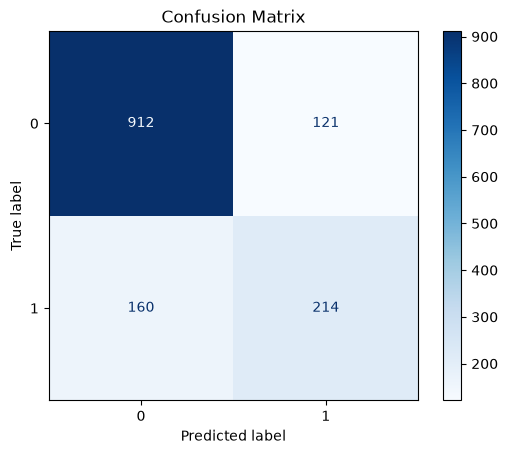

In [18]:
# ============================================================
# Confusion Matrix
# ============================================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

### Observation

The confusion matrix visualizes the number of correct and incorrect predictions for each class, helping identify the strengths and weaknesses of the classification model.

### 📈 14.4 ROC Curve

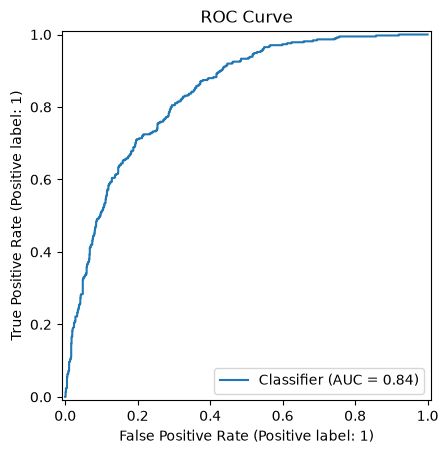

In [19]:
# ============================================================
# ROC Curve
# ============================================================

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve")
plt.show()

### Observation

The ROC Curve illustrates the trade-off between the True Positive Rate and False Positive Rate across different decision thresholds. A higher ROC-AUC indicates better classification performance.

## 💾 15. Save Model and Deployment Artifacts

The optimized machine learning model and preprocessing objects are saved using Joblib. These serialized files will be used for deployment in FastAPI and Streamlit applications.

In [20]:
# ============================================================
# Save Model & Preprocessing Objects
# ============================================================

import joblib

joblib.dump(final_model, "../models/final_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(feature_encoder, "../models/feature_encoder.pkl")

print("=" * 65)
print("Deployment Artifacts Saved Successfully")
print("=" * 65)

print("✔ final_model.pkl")
print("✔ scaler.pkl")
print("✔ feature_encoder.pkl")

Deployment Artifacts Saved Successfully
✔ final_model.pkl
✔ scaler.pkl
✔ feature_encoder.pkl


### Observation

The trained model and preprocessing objects have been successfully saved. These artifacts are deployment-ready and can be directly integrated into FastAPI and Streamlit applications without retraining the model.

## 📋 16. Final Model Training Summary

This notebook successfully completed the end-to-end machine learning workflow for customer churn prediction, from data preprocessing to model deployment preparation.

In [21]:
# ============================================================
# Final Training Summary
# ============================================================

print("=" * 70)
print("BusinessPulse-AI : Model Training Summary")
print("=" * 70)

print(f"Dataset                : customer_churn_clean.csv")
print(f"Training Samples       : {X_train.shape[0]}")
print(f"Testing Samples        : {X_test.shape[0]}")
print(f"Total Features         : {X_train.shape[1]}")
print(f"Models Compared        : {len(models)}")
print(f"Best Model             : {best_model_name}")
print(f"Final Accuracy         : {final_accuracy:.4f}")
print(f"Final Precision        : {final_precision:.4f}")
print(f"Final Recall           : {final_recall:.4f}")
print(f"Final F1-Score         : {final_f1:.4f}")
print(f"Final ROC-AUC          : {final_auc:.4f}")
print("Deployment Ready       : Yes")
print("=" * 70)

BusinessPulse-AI : Model Training Summary
Dataset                : customer_churn_clean.csv
Training Samples       : 5625
Testing Samples        : 1407
Total Features         : 30
Models Compared        : 9
Best Model             : Logistic Regression
Final Accuracy         : 0.8003
Final Precision        : 0.6388
Final Recall           : 0.5722
Final F1-Score         : 0.6037
Final ROC-AUC          : 0.8352
Deployment Ready       : Yes


### Observation

The complete machine learning pipeline has been successfully executed. The optimized model has been evaluated, serialized, and prepared for deployment. The notebook is now ready for integration with FastAPI, Streamlit, and GitHub portfolio documentation.